# Titanic Dataset - Exploratory Data Analysis (EDA)

## Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on the Titanic dataset using Python.

This analysis includes:

- Loading the dataset
- Cleaning missing data
- Creating new features
- Performing group-wise analysis
- Visualizing important patterns
- Drawing meaningful conclusions

The following questions will be answered:

1. What is the survival rate by age group?
2. Does embarkation port affect survival?
3. Does family size affect survival?
4. What relationships exist between numerical features?

In [23]:
# Import Required Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## Loading the Dataset

The Titanic dataset is loaded into a Pandas DataFrame for further analysis.

In [24]:
df = pd.read_csv("Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Understanding the Dataset

Before performing analysis, it is important to understand the dataset structure and identify missing values.

In [25]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Dataset Shape:
(891, 12)

Column Names:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [26]:
print("Missing Values")

df.isnull().sum()

Missing Values


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Data Cleaning

The following preprocessing steps are performed:

- Missing values in the Age column are filled using the mean age.
- Missing values in the Embarked column are filled using the most frequent value.
- The Cabin column is removed because it contains many missing values.

In [27]:
# Fill missing Age values

df["Age"] = df["Age"].fillna(df["Age"].mean())

# Fill missing Embarked values

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin column

df.drop("Cabin", axis=1, inplace=True)

df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## Creating New Features

Family Size is calculated by combining the number of siblings/spouses (SibSp) and parents/children (Parch).

In [28]:
df["FamilySize"] = df["SibSp"] + df["Parch"]

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


## Question 1

### What is the Survival Rate by Age Group?

Passengers are divided into different age groups to compare survival rates.

In [29]:
bins = [0,12,18,35,60,100]

labels = [
    "Child",
    "Teen",
    "Young Adult",
    "Adult",
    "Senior"
]

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

age_survival = df.groupby("AgeGroup")["Survived"].mean()*100

print(age_survival)

AgeGroup
Child          57.971014
Teen           42.857143
Young Adult    35.327103
Adult          40.000000
Senior         22.727273
Name: Survived, dtype: float64


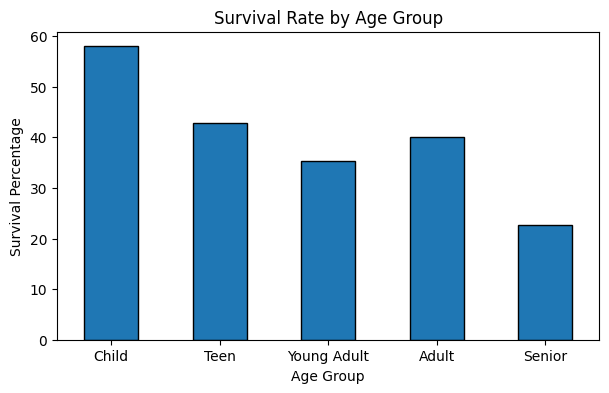

In [30]:
age_survival.plot(
    kind="bar",
    figsize=(7,4),
    edgecolor= "black"
)

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Percentage")

plt.xticks(rotation=0)

plt.show()

## Observation

Children generally showed higher survival rates compared to senior passengers.

## Question 2

### What is the Survival Rate by Embarkation Port?

The survival rate is compared for passengers who boarded from different embarkation ports.

In [31]:
embarked_survival = df.groupby("Embarked")["Survived"].mean()*100

print(embarked_survival)

Embarked
C    55.357143
Q    38.961039
S    33.900929
Name: Survived, dtype: float64


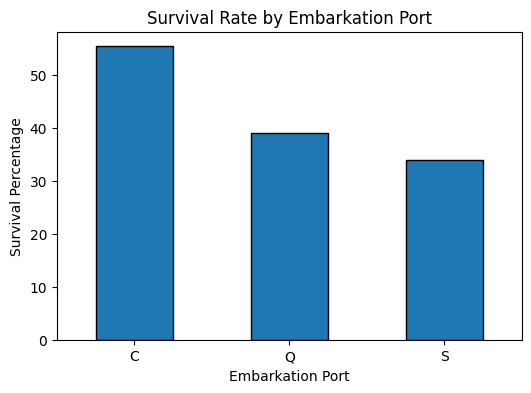

In [32]:
embarked_survival.plot(
    kind="bar",
    figsize=(6,4), 
    edgecolor= "black"
)

plt.title("Survival Rate by Embarkation Port")
plt.xlabel("Embarkation Port")
plt.ylabel("Survival Percentage")

plt.xticks(rotation=0)

plt.show()

## Observation

Survival rates varied across embarkation ports, indicating that boarding location may have influenced passenger survival.

## Question 3

### Does Family Size Affect Survival?

Family size is calculated using SibSp and Parch columns.

In [33]:
family_survival = df.groupby("FamilySize")["Survived"].mean()*100

print(family_survival)

FamilySize
0     30.353818
1     55.279503
2     57.843137
3     72.413793
4     20.000000
5     13.636364
6     33.333333
7      0.000000
10     0.000000
Name: Survived, dtype: float64


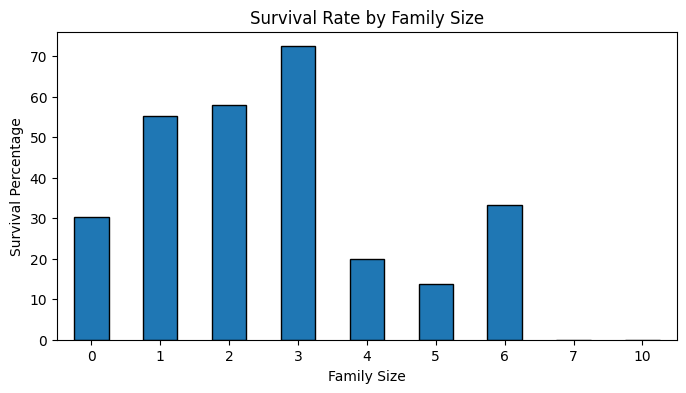

In [34]:
family_survival.plot(
    kind="bar",
    figsize=(8,4), 
    edgecolor= "black"
)

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Percentage")

plt.xticks(rotation=0)

plt.show()

## Observation

Passengers travelling with small families generally showed higher survival rates than those travelling alone or in very large families.

## Visualization

### Distribution of Passenger Ages

A histogram is used to understand the distribution of passenger ages.

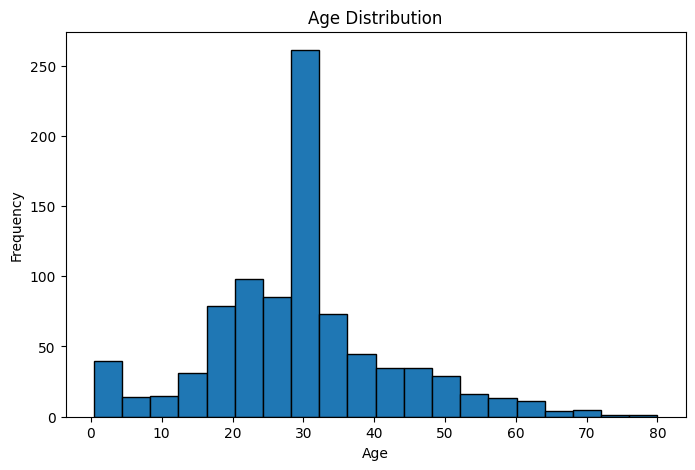

In [35]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Age"],
    bins=20, edgecolor= "black"
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

## Visualization

### Correlation Heatmap

A heatmap is created to visualize correlations between numerical variables.

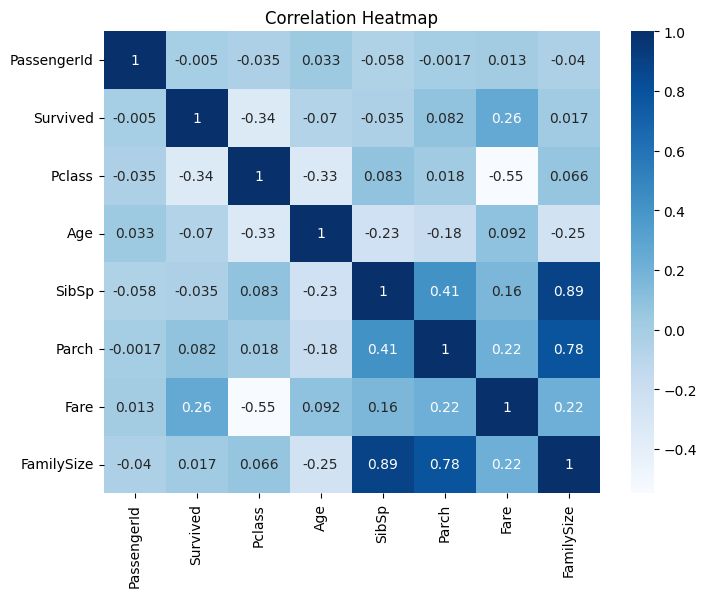

In [36]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")

plt.show()

## Final Conclusion

The exploratory data analysis of the Titanic dataset revealed several important insights:

1. Children generally had better survival rates than senior passengers.
2. Survival rates varied across embarkation ports.
3. Family size influenced survival, with passengers travelling in smaller families generally showing better survival rates.
4. The age distribution indicated that most passengers were young adults.
5. The correlation heatmap highlighted relationships between numerical features and survival.

Overall, this project demonstrates how Exploratory Data Analysis (EDA) can be used to discover hidden patterns and relationships within real-world datasets using Python, Pandas, Matplotlib, and Seaborn.